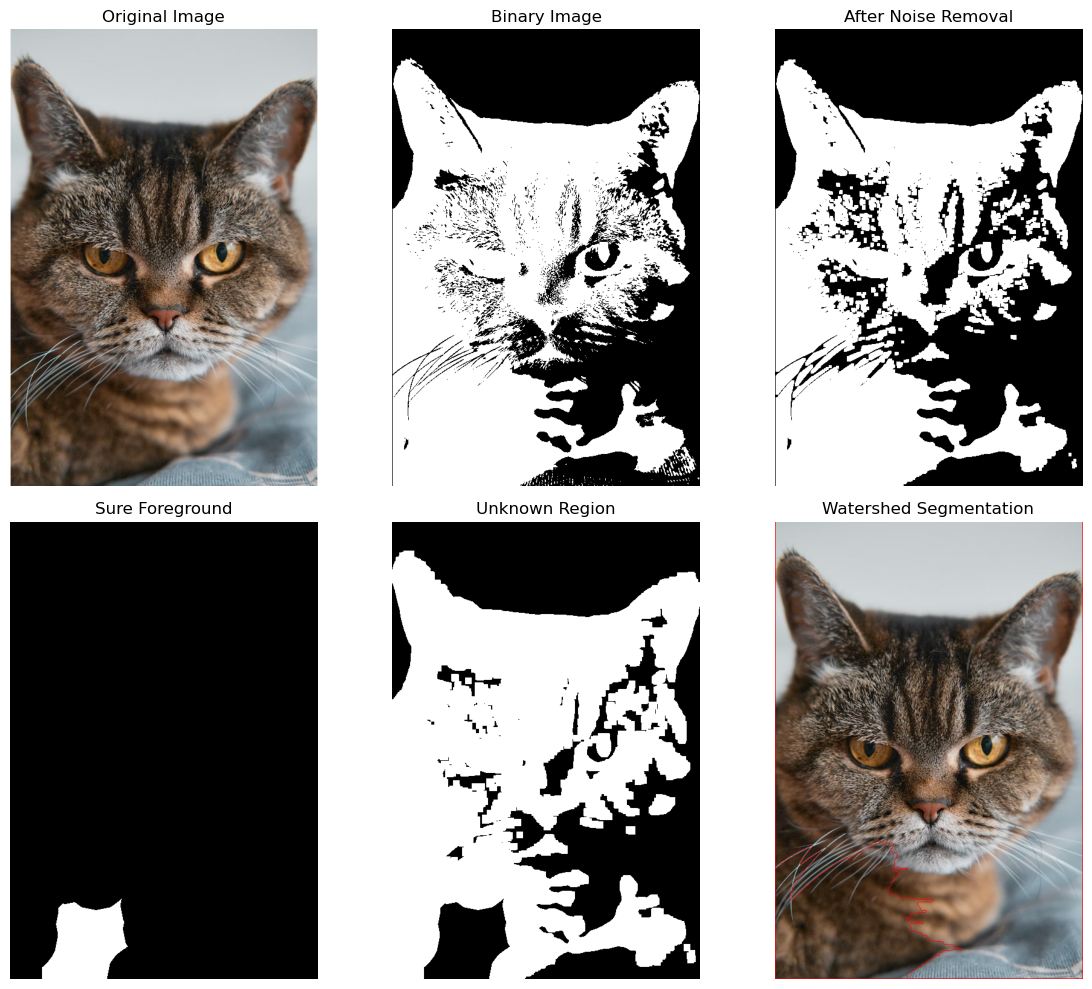

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read Image
image = cv2.imread("cat.png")

original = image.copy()

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)


# 1. Thresholding
_, binary = cv2.threshold(
    gray,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)


# 2. Noise Removal
kernel = np.ones((3, 3), np.uint8)

opening = cv2.morphologyEx(
    binary,
    cv2.MORPH_OPEN,
    kernel,
    iterations=2
)


# 3. Sure Background
sure_bg = cv2.dilate(
    opening,
    kernel,
    iterations=3
)


# 4. Distance Transform
dist_transform = cv2.distanceTransform(
    opening,
    cv2.DIST_L2,
    5
)


# 5. Sure Foreground
_, sure_fg = cv2.threshold(
    dist_transform,
    0.5 * dist_transform.max(),
    255,
    0
)

sure_fg = np.uint8(sure_fg)


# 6. Unknown Region
unknown = cv2.subtract(
    sure_bg,
    sure_fg
)


# 7. Create Markers
num_labels, markers = cv2.connectedComponents(
    sure_fg
)

# Add 1 to all labels
markers = markers + 1

# Mark unknown region as 0
markers[unknown == 255] = 0


# 8. Apply Watershed
markers = cv2.watershed(
    image,
    markers
)

# 9. Mark Watershed Boundaries
result = original.copy()

# Watershed boundaries have marker value -1
result[markers == -1] = [0, 0, 255]


# Display Results
plt.figure(figsize=(12, 10))

plt.subplot(2, 3, 1)
plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(binary, cmap="gray")
plt.title("Binary Image")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(opening, cmap="gray")
plt.title("After Noise Removal")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(sure_fg, cmap="gray")
plt.title("Sure Foreground")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(unknown, cmap="gray")
plt.title("Unknown Region")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Watershed Segmentation")
plt.axis("off")

plt.tight_layout()
plt.show()